In [1]:
import pandas as pd
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Baseline I: predicting binding from pMHC perspective, using NetMHCpan

In [2]:
df_orig = pd.read_csv("../Data/TCRneo_duplex_fingerprint_data_WT_TCR.tsv", sep="\t")
df_netmhc = pd.read_csv("../Results/netmhcpan_baseline_cleaned.tsv", skiprows=2, sep="\t")

Creating a matrix 

In [ ]:
# Joining with the original dataset to get peptide_pos and peptide_res
df_merged = pd.merge(
    df_orig[["Peptide_pos", "Peptide_res", "Peptide_seq"]],
    df_netmhc[["Peptide", "EL_score", "EL_rank"]],
    left_on="Peptide_seq",
    right_on="Peptide",
    how="inner",
)

# Creating 2 matrices for the heatmaps (one rank, one score)
df_mut = df_merged[df_merged["Peptide_pos"] > 0]

matrix_score = df_mut.pivot(
    index="Peptide_res", columns="Peptide_pos", values="EL_score"
).sort_index()

matrix_rank = df_mut.pivot(
    index="Peptide_res", columns="Peptide_pos", values="EL_rank"
).sort_index()

# Adding back the WT sequence score
wt_score = df_merged.loc[df_merged["Peptide_pos"] == 0, "EL_score"].values[0]
wt_rank = df_merged.loc[df_merged["Peptide_pos"] == 0, "EL_rank"].values[0]
wt_seq = "NLFRRVWEL"

for pos, aa in enumerate(wt_seq, start=1):
    if aa in matrix_score.index and pos in matrix_score.columns:
        matrix_score.loc[aa, pos] = wt_score

for pos, aa in enumerate(wt_seq, start=1):
    if aa in matrix_rank.index and pos in matrix_rank.columns:
        matrix_rank.loc[aa, pos] = wt_rank


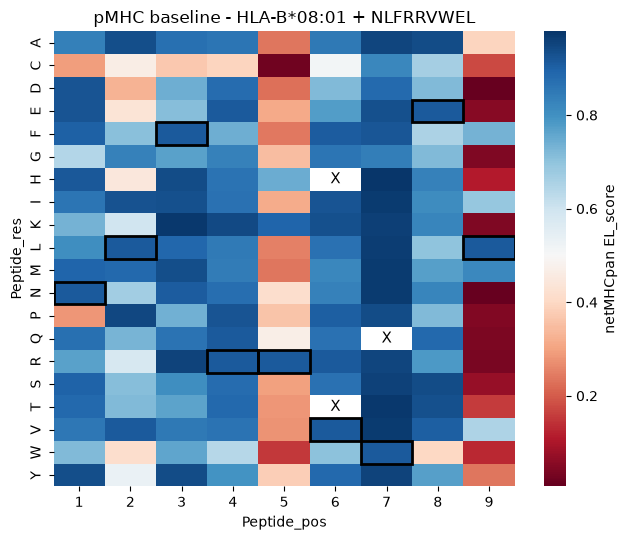

In [20]:
# Heatmap plot for the score matrix
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(
    matrix_score,
    cmap="RdBu",
    center=0.5,
    cbar_kws={"label": "netMHCpan EL_score"},
    ax=ax,
)

# Highlighting the WT sequence 
wt_seq = "NLFRRVWEL"
for pos, aa in enumerate(wt_seq, start=1):
    if aa in matrix_score.index and pos in matrix_score.columns:
        x = matrix_score.columns.get_loc(pos)
        y = matrix_score.index.get_loc(aa)
        ax.add_patch(
            patches.Rectangle(
                (x, y), 1, 1, fill=False, edgecolor="black", lw=2
            )
        )

# Crossing out the residues without data
for r_idx, aa in enumerate(matrix_score.index):
    for c_idx, pos in enumerate(matrix_score.columns):
        if pd.isna(matrix_score.loc[aa, pos]):
            ax.text(
                c_idx + 0.5,
                r_idx + 0.5,
                "X",
                ha="center",
                va="center",
                color="black",
                fontsize=11,
            )

ax.set_title("pMHC baseline - HLA-B*08:01 + NLFRRVWEL")
ax.set_xlabel("Peptide_pos")
ax.set_ylabel("Peptide_res")
plt.tight_layout()
plt.show()

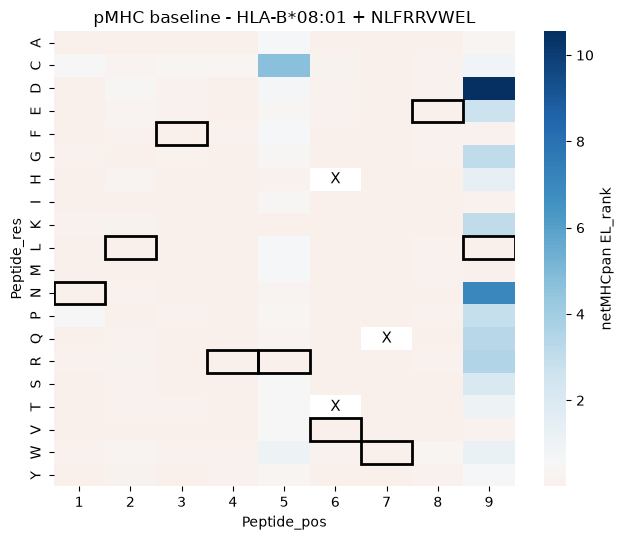

In [43]:
# Heatmap plot for the rank matrix
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(
    matrix_rank,
    cmap="RdBu",
    center=0.5,
    cbar_kws={"label": "netMHCpan EL_rank"},
    ax=ax,
)

# Highlighting the WT sequence 
wt_seq = "NLFRRVWEL"
for pos, aa in enumerate(wt_seq, start=1):
    if aa in matrix_rank.index and pos in matrix_rank.columns:
        x = matrix_rank.columns.get_loc(pos)
        y = matrix_rank.index.get_loc(aa)
        ax.add_patch(
            patches.Rectangle(
                (x, y), 1, 1, fill=False, edgecolor="black", lw=2
            )
        )

# Crossing out the residues without data
for r_idx, aa in enumerate(matrix_rank.index):
    for c_idx, pos in enumerate(matrix_rank.columns):
        if pd.isna(matrix_rank.loc[aa, pos]):
            ax.text(
                c_idx + 0.5,
                r_idx + 0.5,
                "X",
                ha="center",
                va="center",
                color="black",
                fontsize=11,
            )

ax.set_title("pMHC baseline - HLA-B*08:01 + NLFRRVWEL")
ax.set_xlabel("Peptide_pos")
ax.set_ylabel("Peptide_res")
plt.tight_layout()
plt.show()

## Baseline II: predicting binding from TCR perspective

Importing Blosum Matrix

In [35]:
alphabet_file = "../Data/Matrices/alphabet"
alphabet = np.loadtxt("../Data/Matrices/alphabet", dtype=str)

alphabet

blosum_file = "../Data/Matrices/BLOSUM62"
_blosum62 = np.loadtxt(blosum_file, dtype=int, skiprows=1, usecols=range(1, 21)).T

blosum62 = {}

for i, letter_1 in enumerate(alphabet):
    
    blosum62[letter_1] = {}

    for j, letter_2 in enumerate(alphabet):
        
        blosum62[letter_1][letter_2] = _blosum62[i, j]
        
blosum62      

{np.str_('A'): {np.str_('A'): np.int64(4),
  np.str_('R'): np.int64(-1),
  np.str_('N'): np.int64(-2),
  np.str_('D'): np.int64(-2),
  np.str_('C'): np.int64(0),
  np.str_('Q'): np.int64(-1),
  np.str_('E'): np.int64(-1),
  np.str_('G'): np.int64(0),
  np.str_('H'): np.int64(-2),
  np.str_('I'): np.int64(-1),
  np.str_('L'): np.int64(-1),
  np.str_('K'): np.int64(-1),
  np.str_('M'): np.int64(-1),
  np.str_('F'): np.int64(-2),
  np.str_('P'): np.int64(-1),
  np.str_('S'): np.int64(1),
  np.str_('T'): np.int64(0),
  np.str_('W'): np.int64(-3),
  np.str_('Y'): np.int64(-2),
  np.str_('V'): np.int64(0)},
 np.str_('R'): {np.str_('A'): np.int64(-1),
  np.str_('R'): np.int64(5),
  np.str_('N'): np.int64(0),
  np.str_('D'): np.int64(-2),
  np.str_('C'): np.int64(-3),
  np.str_('Q'): np.int64(1),
  np.str_('E'): np.int64(0),
  np.str_('G'): np.int64(-2),
  np.str_('H'): np.int64(0),
  np.str_('I'): np.int64(-3),
  np.str_('L'): np.int64(-2),
  np.str_('K'): np.int64(2),
  np.str_('M'): np.int6

Creating and filling 2 matrices: 1 with an absolute score, and another with a score relative to the WT/WT substitution

In [36]:
matrix_tcr = pd.DataFrame(index=alphabet, columns=range(1, 10), dtype=float)

# Absolute matrix
wt_seq = "NLFRRVWEL"
for pos, wt_aa in enumerate(wt_seq, start=1):
    for aa in alphabet:
        matrix_tcr.loc[aa, pos] = blosum62[wt_aa][aa]

#Optional, to mask the 3 peptides without experimental data
matrix_tcr.loc["H", 6] = np.nan
matrix_tcr.loc["T", 6] = np.nan
matrix_tcr.loc["Q", 7] = np.nan

#sorting the residues to obtain the same order as in the Baseline I
matrix_tcr = matrix_tcr.sort_index()

# Relative matrix
matrix_tcr_rel = matrix_tcr.copy()
for pos, wt_aa in enumerate(wt_seq, start=1):
    wt_val = blosum62[wt_aa][wt_aa]
    matrix_tcr_rel[pos] = matrix_tcr_rel[pos] - wt_val

#Masking back the missing data
matrix_tcr_rel.loc["H", 6] = np.nan
matrix_tcr_rel.loc["T", 6] = np.nan
matrix_tcr_rel.loc["Q", 7] = np.nan


Plotting the absolute matrix

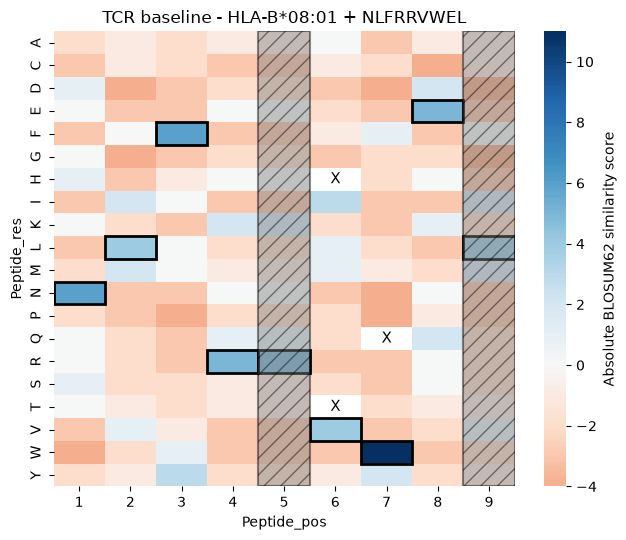

In [40]:
# Heatmap plot for the score matrix
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(
    matrix_tcr,
    cmap="RdBu",
    center=0,
    cbar_kws={"label": "Absolute BLOSUM62 similarity score"},
    ax=ax,
)

# Highlighting the WT sequence 
wt_seq = "NLFRRVWEL"
for pos, aa in enumerate(wt_seq, start=1):
    if aa in matrix_tcr.index and pos in matrix_tcr.columns:
        x = matrix_tcr.columns.get_loc(pos)
        y = matrix_tcr.index.get_loc(aa)
        ax.add_patch(
            patches.Rectangle(
                (x, y), 1, 1, fill=False, edgecolor="black", lw=2
            )
        )

# Crossing out the residues without data
for r_idx, aa in enumerate(matrix_tcr.index):
    for c_idx, pos in enumerate(matrix_tcr.columns):
        if pd.isna(matrix_tcr.loc[aa, pos]):
            ax.text(
                c_idx + 0.5,
                r_idx + 0.5,
                "X",
                ha="center",
                va="center",
                color="black",
                fontsize=11,
            )

# Crossing out the 2 residues identified in Baseline 1
n_rows = len(matrix_tcr_rel.index)
for anchor_pos in [5, 9]:
    col_idx = matrix_tcr_rel.columns.get_loc(anchor_pos)
    ax.add_patch(
        patches.Rectangle(
            (col_idx, 0),
            1,
            n_rows,
            facecolor="gray",
            alpha=0.45,
            hatch="//",
            edgecolor="black",
            linewidth=1.5,
        )
    )

ax.set_title("TCR baseline - HLA-B*08:01 + NLFRRVWEL")
ax.set_xlabel("Peptide_pos")
ax.set_ylabel("Peptide_res")
plt.tight_layout()
plt.show()

Plotting the relative matrix

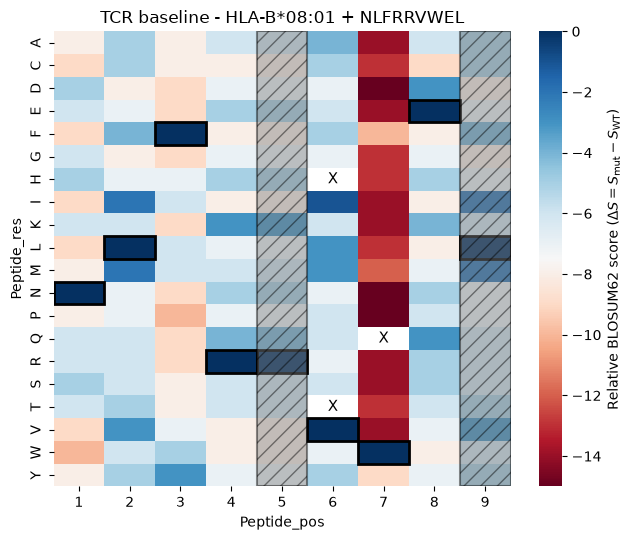

In [41]:
# Heatmap plot for the score matrix
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(
    matrix_tcr_rel,
    cmap="RdBu",
    cbar_kws = {"label": r"Relative BLOSUM62 score ($\Delta S = S_{\mathrm{mut}} - S_{\mathrm{WT}}$)"},
    ax=ax,
)

# Highlighting the WT sequence 
wt_seq = "NLFRRVWEL"
for pos, aa in enumerate(wt_seq, start=1):
    if aa in matrix_tcr_rel.index and pos in matrix_tcr_rel.columns:
        x = matrix_tcr_rel.columns.get_loc(pos)
        y = matrix_tcr_rel.index.get_loc(aa)
        ax.add_patch(
            patches.Rectangle(
                (x, y), 1, 1, fill=False, edgecolor="black", lw=2
            )
        )

# Crossing out the residues without data
for r_idx, aa in enumerate(matrix_tcr_rel.index):
    for c_idx, pos in enumerate(matrix_tcr_rel.columns):
        if pd.isna(matrix_tcr_rel.loc[aa, pos]):
            ax.text(
                c_idx + 0.5,
                r_idx + 0.5,
                "X",
                ha="center",
                va="center",
                color="black",
                fontsize=11,
            )

# Crossing out the 2 residues identified in Baseline 1
n_rows = len(matrix_tcr_rel.index)
for anchor_pos in [5, 9]:
    col_idx = matrix_tcr_rel.columns.get_loc(anchor_pos)
    ax.add_patch(
        patches.Rectangle(
            (col_idx, 0),
            1,
            n_rows,
            facecolor="gray",
            alpha=0.45,
            hatch="//",
            edgecolor="black",
            linewidth=1.5,
        )
    )

ax.set_title("TCR baseline - HLA-B*08:01 + NLFRRVWEL")
ax.set_xlabel("Peptide_pos")
ax.set_ylabel("Peptide_res")
plt.tight_layout()
plt.show()